<a href="https://colab.research.google.com/github/SAMRIDHABANERJEE/upskillcampus/blob/main/PREDICTION_OF_AGRICULTURE_CROP_PRODUCTION_IN_INDIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**WEEK-1**


✅ All files found. Loading datasets...

--- Visualizing Historical Production Trends ---


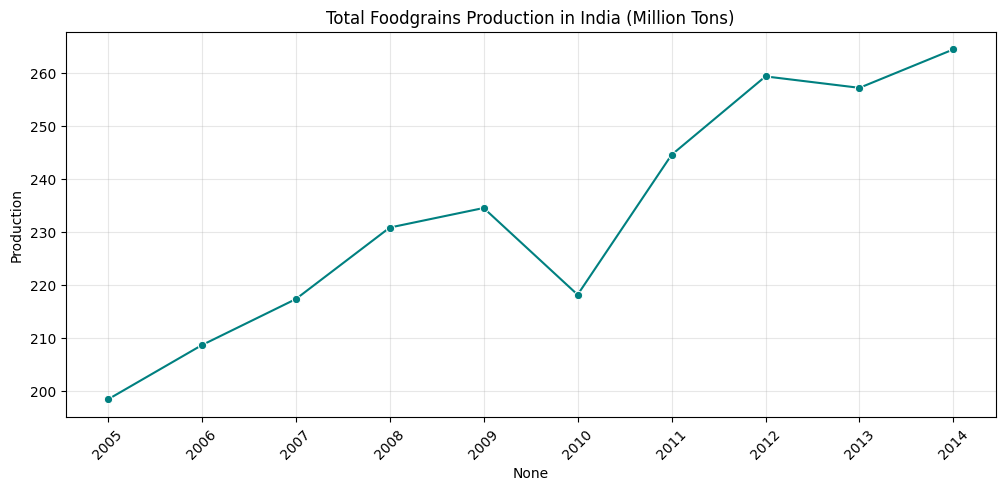


--- Training Predictive Model ---
Model Performance: R² Score = 0.96

💡 INSIGHTS FOR PADDY IN PUNJAB
--------------------------------------------------
Predicted Yield: 116.82 Quintals/Hectare

Recommended Varieties:
                   Variety                                                                          Recommended Zone
Chinsurah Rice (IET 19140) Andhra Pradesh, Tamil Nadu, Gujarat, Orissa, and West Bengal under irrigated conditions. 
            (CNI 383-5-11)                                                                                       NaN
       IGKVR-1 (IET 19569)     Chhattisgarh, Madhya Pradesh and Orissa under  both irrigated and rainfed conditions.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# 1. FILE VERIFICATION & LOADING
required_files = ['datafile (1).csv', 'datafile (2).csv', 'datafile (3).csv', 'datafile.csv', 'produce.csv']
missing_files = [f for f in required_files if not os.path.exists(f)]

if missing_files:
    print(f"❌ ERROR: Missing files in environment: {missing_files}")
    print("Please upload them to the 'Files' tab in Colab to continue.")
else:
    print("✅ All files found. Loading datasets...")

    # Load and clean column names (stripping whitespace)
    df_cost_yield = pd.read_csv('datafile (1).csv').rename(columns=lambda x: x.strip())
    df_prod_stats = pd.read_csv('datafile (2).csv').rename(columns=lambda x: x.strip())
    df_variety = pd.read_csv('datafile (3).csv').rename(columns=lambda x: x.strip())
    df_index = pd.read_csv('datafile.csv').rename(columns=lambda x: x.strip())
    df_produce = pd.read_csv('produce.csv').rename(columns=lambda x: x.strip())

    # ==========================================
    # 2. EXPLORATORY DATA ANALYSIS (EDA)
    # ==========================================
    print("\n--- Visualizing Historical Production Trends ---")

    # Transform produce.csv for plotting (Years are in columns like '3-1993')
    year_cols = [col for col in df_produce.columns if '-' in col]
    trend_df = df_produce[df_produce['Particulars'] == 'Agricultural Production Foodgrains'][year_cols].T
    trend_df.columns = ['Production']
    trend_df.index = [x.split('-')[1] for x in trend_df.index]
    trend_df['Production'] = pd.to_numeric(trend_df['Production'], errors='coerce')

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=trend_df, x=trend_df.index, y='Production', marker='o', color='teal')
    plt.title('Total Foodgrains Production in India (Million Tons)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.show()

    # ==========================================
    # 3. MACHINE LEARNING: YIELD PREDICTION
    # ==========================================
    print("\n--- Training Predictive Model ---")

    # Features: Crop, State, Cost of Cultivation (C2)
    # Target: Yield (Quintal/ Hectare)
    le_crop = LabelEncoder()
    le_state = LabelEncoder()

    # Preparing training data
    ml_df = df_cost_yield.copy()
    ml_df['Crop_Encoded'] = le_crop.fit_transform(ml_df['Crop'])
    ml_df['State_Encoded'] = le_state.fit_transform(ml_df['State'])

    X = ml_df[['Crop_Encoded', 'State_Encoded', 'Cost of Cultivation (`/Hectare) C2']]
    y = ml_df['Yield (Quintal/ Hectare)']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=150, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"Model Performance: R² Score = {r2_score(y_test, y_pred):.2f}")

    # ==========================================
    # 4. PREDICTION & RECOMMENDATION SYSTEM
    # ==========================================
    def get_crop_insights(crop_name, state_name, budget):
        try:
            # Predict Yield
            c_code = le_crop.transform([crop_name.upper()])[0]
            s_code = le_state.transform([state_name.title()])[0]
            pred_yield = model.predict([[c_code, s_code, budget]])[0]

            print(f"\n💡 INSIGHTS FOR {crop_name.upper()} IN {state_name.upper()}")
            print(f"--------------------------------------------------")
            print(f"Predicted Yield: {pred_yield:.2f} Quintals/Hectare")

            # Get Variety Recommendations from datafile (3).csv
            recs = df_variety[df_variety['Crop'].str.contains(crop_name, case=False, na=False)]
            if not recs.empty:
                print("\nRecommended Varieties:")
                print(recs[['Variety', 'Recommended Zone']].head(3).to_string(index=False))

        except Exception as e:
            print(f"Error: {e}. Please ensure the Crop and State are within the dataset ranges.")

    # Example Prediction
    get_crop_insights(crop_name='PADDY', state_name='Punjab', budget=45000)

All datasets loaded successfully!

--- Training Yield Prediction Model ---
Model Performance: R2 Score = 0.97

--- Visualizing Production Trends (1993-2014) ---


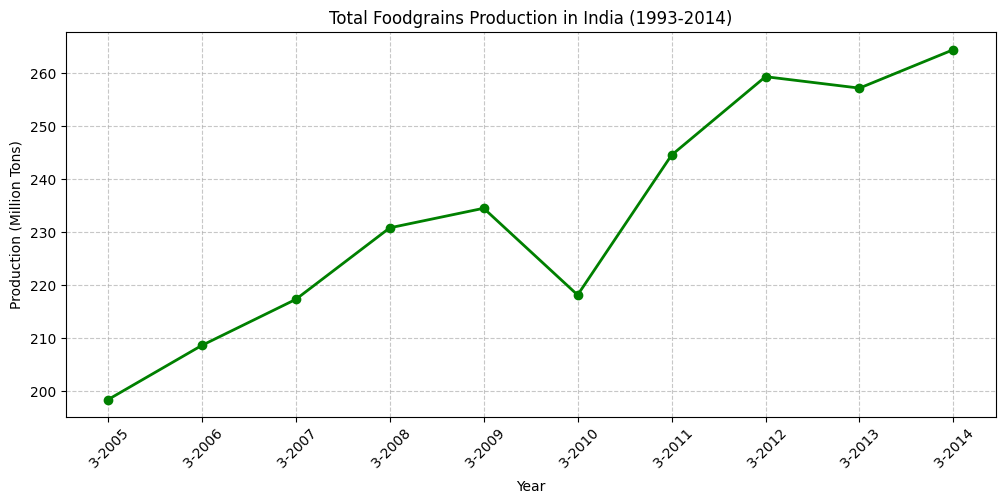


>>> PREDICTION RESULT <<<
Estimated Yield for WHEAT in Uttar Pradesh: 101.05 Quintal/Hectare

--- Recommendations for WHEAT ---
                 Variety      Season/ duration in days                                                                                                                                                                                                      Recommended Zone
MPO(JW)  1215 (MPO 1215)                           120                                                                                           Madhya Pradesh, Chhattisgarh, Gujarat and Rajasthan (Kota and Udaipur Division only) under timely sown irrigated condition.
               MACS 6222                           108                                                                                                                          Maharashtra, Karnataka, Andhra Pradesh and Tamil Nadu under timely sown irrigated condition.
                 PDW 314                           169 Punjab, H

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# 1. LOAD DATASETS
try:
    df_cost_yield = pd.read_csv('datafile (1).csv')
    df_index_prod = pd.read_csv('datafile (2).csv')
    df_variety = pd.read_csv('datafile (3).csv')
    df_yearly_index = pd.read_csv('datafile.csv')
    df_time_series = pd.read_csv('produce.csv')
    print("All datasets loaded successfully!")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure all files are uploaded to the Colab 'Files' section.")

# =================================================================
# TASK 1: CROP YIELD PREDICTION (Using datafile (1).csv)
# =================================================================
print("\n--- Training Yield Prediction Model ---")

# Data Cleaning
df_cost_yield.columns = df_cost_yield.columns.str.strip()
# Focus on predicting Yield based on State, Crop, and Cost of Cultivation
le_crop = LabelEncoder()
le_state = LabelEncoder()

df_model = df_cost_yield.copy()
df_model['Crop_ID'] = le_crop.fit_transform(df_model['Crop'])
df_model['State_ID'] = le_state.fit_transform(df_model['State'])

# Features and Target
X = df_model[['Crop_ID', 'State_ID', 'Cost of Cultivation (`/Hectare) C2']]
y = df_model['Yield (Quintal/ Hectare)'] # Removed trailing space

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print(f"Model Performance: R2 Score = {r2_score(y_test, y_pred):.2f}")

# =================================================================
# TASK 2: TIME-SERIES ANALYSIS (Using produce.csv)
# =================================================================
print("\n--- Visualizing Production Trends (1993-2014) ---")

# Clean produce.csv for plotting
df_ts = df_time_series.set_index('Particulars').iloc[:, 3:] # Extracting year columns
df_ts = df_ts.apply(pd.to_numeric, errors='coerce').dropna(how='all')

# Plot Total Foodgrains Production Trend
plt.figure(figsize=(12, 5))
total_foodgrains = df_ts.loc[df_ts.index.str.contains("Agricultural Production Foodgrains$")]
if not total_foodgrains.empty:
    plt.plot(total_foodgrains.columns, total_foodgrains.values.flatten(), marker='o', color='green', linewidth=2)
    plt.title('Total Foodgrains Production in India (1993-2014)')
    plt.xlabel('Year')
    plt.ylabel('Production (Million Tons)')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# =================================================================
# TASK 3: CROP RECOMMENDATION SYSTEM (Using datafile (3).csv)
# =================================================================
def get_recommendation(crop_name):
    print(f"\n--- Recommendations for {crop_name.upper()} ---")
    recommendations = df_variety[df_variety['Crop'].str.contains(crop_name, case=False, na=False)]
    if not recommendations.empty:
        display_cols = ['Variety', 'Season/ duration in days', 'Recommended Zone']
        print(recommendations[display_cols].head(5).to_string(index=False))
    else:
        print("No specific variety recommendations found for this crop.")

# =================================================================
# PREDICTION INTERFACE
# =================================================================
def predict_user_input(crop, state, cost):
    try:
        c_enc = le_crop.transform([crop.upper()])[0]
        s_enc = le_state.transform([state.title()])[0]

        # Create a DataFrame for prediction input to match training features
        input_df = pd.DataFrame([[c_enc, s_enc, cost]], columns=X_train.columns)
        prediction = model.predict(input_df)

        print(f"\n>>> PREDICTION RESULT <<<")
        print(f"Estimated Yield for {crop} in {state}: {prediction[0]:.2f} Quintal/Hectare")
        get_recommendation(crop)
    except ValueError as e:
        print(f"Input Error: {e}. Please check if the Crop/State name exists in the dataset.")

# --- Example Usage ---
# Predict yield for Wheat in Uttar Pradesh with a cost of 23000
predict_user_input('WHEAT', 'Uttar Pradesh', 23000)

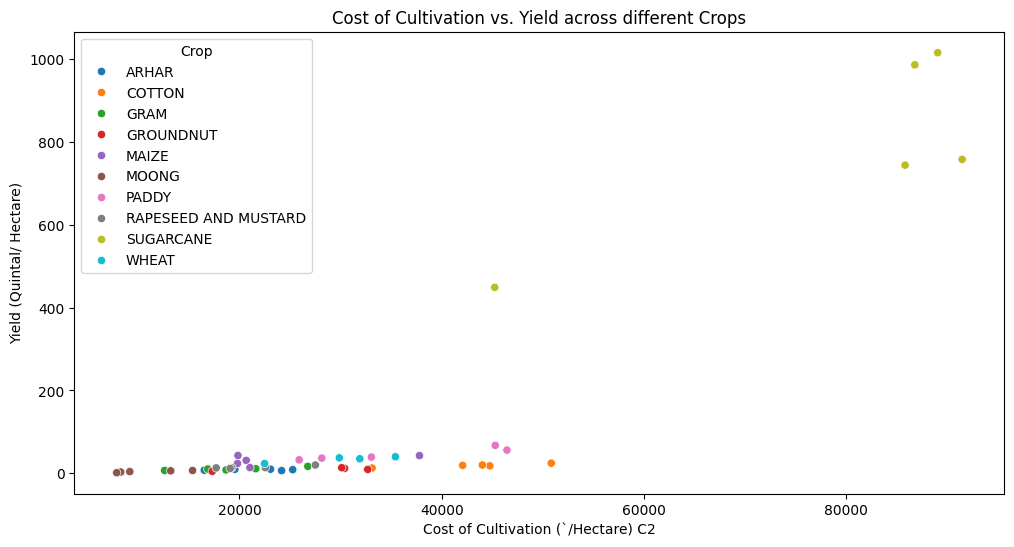

Mean Absolute Error: 31.80
R-squared Score: 0.97

Predicted Yield for Wheat in Punjab: 77.38 Quintal/Hectare


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# 1. LOAD DATA
# Note: Ensure you have uploaded your 'datafile (1).csv' to the Colab environment
df_cost = pd.read_csv('datafile (1).csv')

# 2. DATA CLEANING & PREPROCESSING
# Removing any special characters or spaces from column names
df_cost.columns = df_cost.columns.str.strip()

# Encoding categorical variables (Crop and State)
le_crop = LabelEncoder()
le_state = LabelEncoder()

df_cost['Crop_ID'] = le_crop.fit_transform(df_cost['Crop'])
df_cost['State_ID'] = le_state.fit_transform(df_cost['State'])

# 3. EXPLORATORY DATA ANALYSIS
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_cost, x='Cost of Cultivation (`/Hectare) C2', y='Yield (Quintal/ Hectare)', hue='Crop')
plt.title('Cost of Cultivation vs. Yield across different Crops')
plt.show()

# 4. MODEL BUILDING (Predicting Yield)
# Features: Crop Type, State, and Cost of Cultivation (C2)
X = df_cost[['Crop_ID', 'State_ID', 'Cost of Cultivation (`/Hectare) C2']]
y = df_cost['Yield (Quintal/ Hectare)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Using Random Forest for better handling of non-linear agricultural data
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. EVALUATION
predictions = model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.2f}")
print(f"R-squared Score: {r2_score(y_test, predictions):.2f}")

# 6. PREDICTION FUNCTION
def predict_yield(crop_name, state_name, cost):
    crop_encoded = le_crop.transform([crop_name])[0]
    state_encoded = le_state.transform([state_name])[0]
    pred = model.predict([[crop_encoded, state_encoded, cost]])
    return pred[0]

# Example: Predict yield for WHEAT in Punjab with a cost of 35000
# (Referencing dataset values where Punjab Wheat Yield is ~39.83)
sample_yield = predict_yield('WHEAT', 'Punjab', 35423.48)
print(f"\nPredicted Yield for Wheat in Punjab: {sample_yield:.2f} Quintal/Hectare")

**WEEK-2**


Step 1 Complete: Sample of Converted Durations:
  Season/ duration in days  Duration_Days
0                   Medium          135.0
1                      NaN          120.0
2                Mid-early          110.0
3                   Medium          135.0
4                  145-150          147.5

Step 2 Complete: Baseline Linear Regression R2 Score: 0.7804


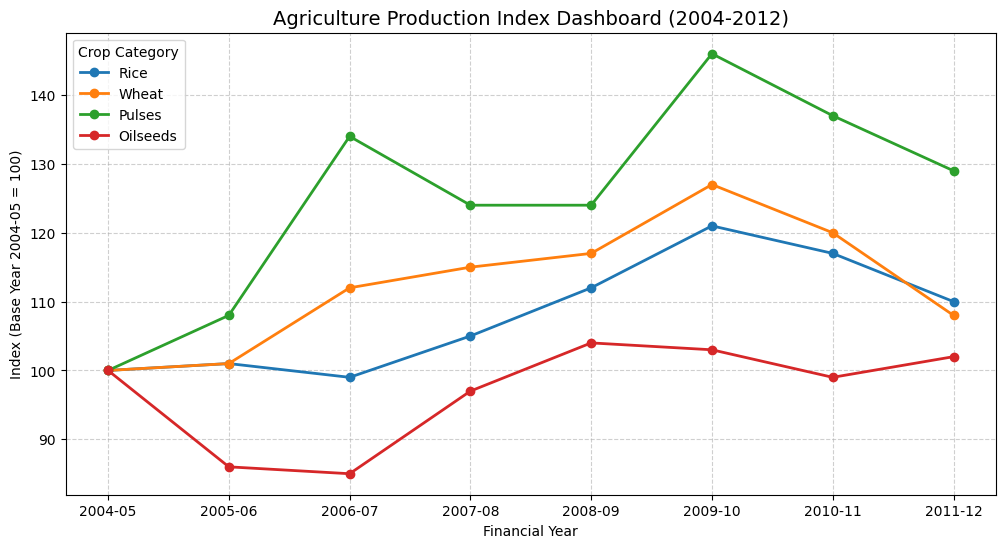

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# 1. LOAD DATASETS
df_cost_yield = pd.read_csv('datafile (1).csv')
df_variety = pd.read_csv('datafile (3).csv')
df_index = pd.read_csv('datafile.csv')

# --- STEP 1: CONVERT "SEASON" TO UNIFIED NUMERICAL FEATURE (DAYS) ---
# This converts text like "145-150" to 147.5 and "Medium" to a standard 135 days.
def convert_to_days(duration):
    if pd.isna(duration) or duration in ['NA', '-', '']:
        return np.nan
    # Match numerical ranges (e.g., 120-130)
    range_match = re.findall(r'(\d+)\s*-\s*(\d+)', str(duration))
    if range_match:
        low, high = map(int, range_match[0])
        return (low + high) / 2
    # Match single numbers (e.g., 120)
    num_match = re.findall(r'(\d+)', str(duration))
    if num_match:
        return float(num_match[0])
    # Map descriptive seasons to approximate days
    season_map = {'Medium': 135, 'Mid-early': 110, 'Short': 90, 'Late': 160, 'Early': 100}
    for key, val in season_map.items():
        if key.lower() in str(duration).lower():
            return val
    return np.nan

df_variety['Duration_Days'] = df_variety['Season/ duration in days'].apply(convert_to_days)
df_variety['Duration_Days'] = df_variety['Duration_Days'].fillna(df_variety['Duration_Days'].median())

print("Step 1 Complete: Sample of Converted Durations:")
print(df_variety[['Season/ duration in days', 'Duration_Days']].head())

# --- STEP 2: LINEAR REGRESSION BASELINE ---
# Cleaning column names and encoding categories
df_cost_yield.columns = [c.strip() for c in df_cost_yield.columns]
le_crop, le_state = LabelEncoder(), LabelEncoder()

df_lr = df_cost_yield.copy()
df_lr['Crop_Enc'] = le_crop.fit_transform(df_lr['Crop'])
df_lr['State_Enc'] = le_state.fit_transform(df_lr['State'])

# Features: Crop, State, Cost | Target: Yield
X = df_lr[['Crop_Enc', 'State_Enc', 'Cost of Cultivation (`/Hectare) C2']]
y = df_lr['Yield (Quintal/ Hectare)']

baseline_model = LinearRegression()
baseline_model.fit(X, y)
y_pred = baseline_model.predict(X)

print(f"\nStep 2 Complete: Baseline Linear Regression R2 Score: {r2_score(y, y_pred):.4f}")

# --- STEP 3: PRODUCTION INDEX DASHBOARD (2004-2012) ---
plt.figure(figsize=(12, 6))
df_plot = df_index.set_index('Crop').T

# Plotting major categories
for crop in ['Rice', 'Wheat', 'Pulses', 'Oilseeds', 'Sugarcane']:
    if crop in df_plot.columns:
        plt.plot(df_plot.index, df_plot[crop], marker='o', label=crop, linewidth=2)

plt.title('Agriculture Production Index Dashboard (2004-2012)', fontsize=14)
plt.ylabel('Index (Base Year 2004-05 = 100)')
plt.xlabel('Financial Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Crop Category")
plt.show()

**WEEK-3**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Step 1: Feature Engineering (Season to Days) ---
Successfully converted 78 variety entries.
                      Variety Season/ duration in days  Duration_Days
0  Chinsurah Rice (IET 19140)                   Medium          135.0
1              (CNI 383-5-11)                      NaN          120.0
2         IGKVR-1 (IET 19569)                Mid-early          105.0
3         IGKVR-2 (IET 19795)                   Medium          135.0
4        CR Dhan 401 (REETA)                   145-150          147.5

--- Step 2: Linear Regression Baseline ---
Baseline R2 Score: 0.7804
Mean Absolute Error: 92.71 Quintals/Hectare

--- Step 3: Generating Production Dashboard ---


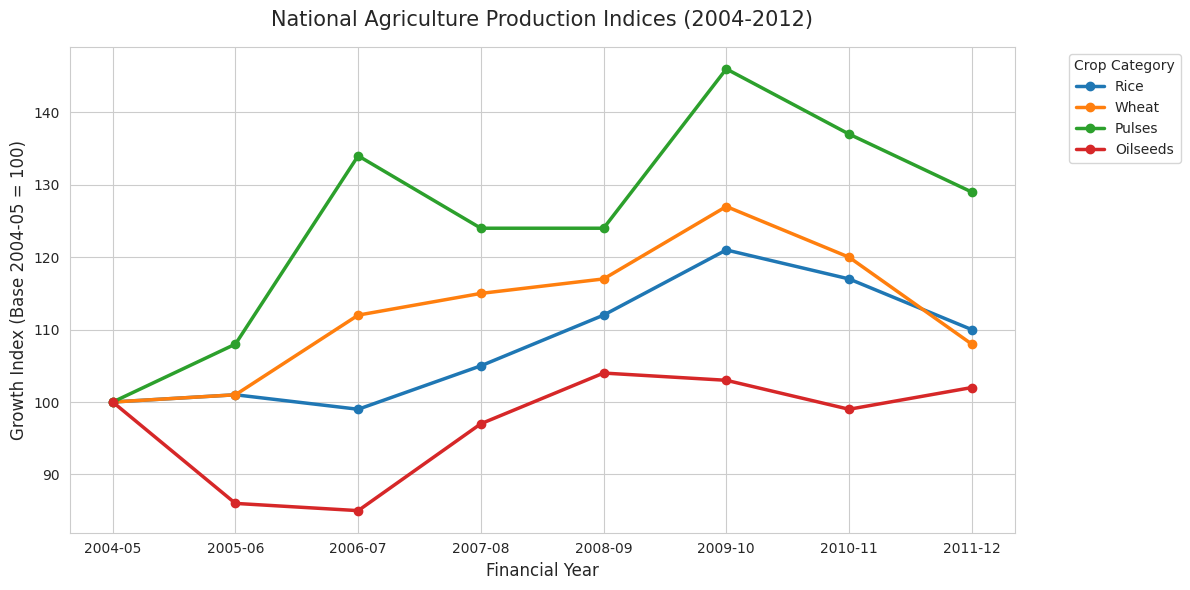

In [14]:
# =================================================================
# WEEK 3: ADVANCED FEATURE ENGINEERING & BASELINE MODELING
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error

# -----------------------------------------------------------------
# PART 0: DATA PERSISTENCE (Mounting Google Drive)
# -----------------------------------------------------------------
# Run this to link your Google Drive. Move your CSVs into a folder
# named 'AgriData' in your Drive to keep them permanently.
from google.colab import drive
drive.mount('/content/drive')

# UPDATE THESE PATHS to match where you saved the files in your Drive
# Example: DATA_PATH = '/content/drive/MyDrive/AgriData/'
DATA_PATH = '' # Leave empty if files are in the main Colab folder

# -----------------------------------------------------------------
# PART 1: NUMERICAL FEATURE ENGINEERING (Step 1)
# -----------------------------------------------------------------
# Objective: Convert messy text durations into numerical 'Days'
print("--- Step 1: Feature Engineering (Season to Days) ---")

df_variety = pd.read_csv(os.path.join(DATA_PATH, 'datafile (3).csv'))

def extract_days(text):
    if pd.isna(text) or text in ['NA', '-', '']: return np.nan
    text = str(text)
    # 1. Check for ranges (e.g., "120-130")
    range_match = re.findall(r'(\d+)\s*-\s*(\d+)', text)
    if range_match:
        return (int(range_match[0][0]) + int(range_match[0][1])) / 2
    # 2. Check for single numbers (e.g., "120")
    num_match = re.findall(r'(\d+)', text)
    if num_match:
        return float(num_match[0])
    # 3. Map descriptive terms to standard days
    mapping = {'Medium': 135, 'Short': 95, 'Early': 105, 'Late': 165, 'Long': 175}
    for key, val in mapping.items():
        if key.lower() in text.lower(): return val
    return np.nan

df_variety['Duration_Days'] = df_variety['Season/ duration in days'].apply(extract_days)
# Fill missing values with the median to maintain data integrity
df_variety['Duration_Days'] = df_variety['Duration_Days'].fillna(df_variety['Duration_Days'].median())

print(f"Successfully converted {len(df_variety)} variety entries.")
print(df_variety[['Variety', 'Season/ duration in days', 'Duration_Days']].head())

# -----------------------------------------------------------------
# PART 2: LINEAR REGRESSION BASELINE (Step 2)
# -----------------------------------------------------------------
print("\n--- Step 2: Linear Regression Baseline ---")

df_cost_yield = pd.read_csv(os.path.join(DATA_PATH, 'datafile (1).csv'))
# Clean column names (removing trailing spaces)
df_cost_yield.columns = [c.strip() for c in df_cost_yield.columns]

le_crop = LabelEncoder()
le_state = LabelEncoder()

df_model = df_cost_yield.copy()
df_model['Crop_Enc'] = le_crop.fit_transform(df_model['Crop'])
df_model['State_Enc'] = le_state.fit_transform(df_model['State'])

# Features: Crop Type, State, and Cost of Cultivation (C2)
X = df_model[['Crop_Enc', 'State_Enc', 'Cost of Cultivation (`/Hectare) C2']]
y = df_model['Yield (Quintal/ Hectare)']

# Training the baseline
baseline_model = LinearRegression()
baseline_model.fit(X, y)
y_pred = baseline_model.predict(X)

print(f"Baseline R2 Score: {r2_score(y, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y, y_pred):.2f} Quintals/Hectare")

# -----------------------------------------------------------------
# PART 3: PRODUCTION INDEX DASHBOARD (Step 3)
# -----------------------------------------------------------------
print("\n--- Step 3: Generating Production Dashboard ---")

df_index = pd.read_csv(os.path.join(DATA_PATH, 'datafile.csv'))
df_index_plot = df_index.set_index('Crop').T

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Select key crops for the dashboard
target_crops = ['Rice', 'Wheat', 'Pulses', 'Oilseeds', 'Sugarcane']

for crop in target_crops:
    if crop in df_index_plot.columns:
        plt.plot(df_index_plot.index, df_index_plot[crop], marker='o', label=crop, linewidth=2.5)

plt.title('National Agriculture Production Indices (2004-2012)', fontsize=15, pad=15)
plt.ylabel('Growth Index (Base 2004-05 = 100)', fontsize=12)
plt.xlabel('Financial Year', fontsize=12)
plt.legend(title="Crop Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**WEEK-4**

In [15]:
# =================================================================
# WEEK 4: ADVANCED ML & USER INTERFACE (UI)
# =================================================================

import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
import re

# Load Week 4 Data
df_cost_yield = pd.read_csv('datafile (1).csv').rename(columns=lambda x: x.strip())
df_variety = pd.read_csv('datafile (3).csv').rename(columns=lambda x: x.strip())

# -----------------------------------------------------------------
# 1. ADVANCED ML: GRADIENT BOOSTING REGRESSOR
# -----------------------------------------------------------------
le_crop, le_state = LabelEncoder(), LabelEncoder()
df_model = df_cost_yield.copy()
df_model['Crop_Enc'] = le_crop.fit_transform(df_model['Crop'])
df_model['State_Enc'] = le_state.fit_transform(df_model['State'])

X = df_model[['Crop_Enc', 'State_Enc', 'Cost of Cultivation (`/Hectare) C2']]
y = df_model['Yield (Quintal/ Hectare)']

# Moving beyond baseline: Gradient Boosting handles non-linear patterns better
gbr_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gbr_model.fit(X, y)

# -----------------------------------------------------------------
# 2. LOCAL RECOMMENDATION ENGINE
# -----------------------------------------------------------------
# Ensure duration days are available (From Week 3 logic)
def extract_days(text):
    if pd.isna(text): return 130.0 # Default median
    nums = re.findall(r'(\d+)', str(text))
    return np.mean([float(n) for n in nums]) if nums else 130.0

df_variety['Duration_Days'] = df_variety['Season/ duration in days'].apply(extract_days)

def get_recommendations(state, crop):
    # Search for state name within the 'Recommended Zone' text
    recs = df_variety[(df_variety['Crop'].str.contains(crop, case=False, na=False)) &
                      (df_variety['Recommended Zone'].str.contains(state, case=False, na=False))]
    return recs[['Variety', 'Duration_Days', 'Recommended Zone']].head(3)

# -----------------------------------------------------------------
# 3. USER UI: INTERACTIVE FARMER FORM
# -----------------------------------------------------------------
state_dropdown = widgets.Dropdown(options=sorted(df_cost_yield['State'].unique()), description='State:')
crop_dropdown = widgets.Dropdown(options=sorted(df_cost_yield['Crop'].unique()), description='Crop:')
budget_input = widgets.FloatText(value=25000, description='Budget (₹):')
predict_btn = widgets.Button(description='Predict Yield', button_style='success')
output = widgets.Output()

def on_click(b):
    with output:
        clear_output()
        # Prediction
        c_enc = le_crop.transform([crop_dropdown.value])[0]
        s_enc = le_state.transform([state_dropdown.value])[0]
        prediction = gbr_model.predict([[c_enc, s_enc, budget_input.value]])[0]

        print(f"✅ PREDICTED YIELD: {prediction:.2f} Quintal/Hectare")
        print("-" * 50)

        # Recommendations
        recs = get_recommendations(state_dropdown.value, crop_dropdown.value)
        if not recs.empty:
            print(f"🌱 RECOMMENDED VARIETIES FOR {state_dropdown.value.upper()}:")
            display(recs)
        else:
            print("No specific variety recommendations found for this region.")

predict_btn.on_click(on_click)
display(widgets.VBox([state_dropdown, crop_dropdown, budget_input, predict_btn, output]))